In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#DataSet 1 (Health Care)
path_health = kagglehub.dataset_download("rabieelkharoua/chronic-kidney-disease-dataset-analysis")
print("Path to dataset files:", path_health)

#DataSet 2 (Marketing)
path_marketing = kagglehub.dataset_download("rodsaldanha/arketing-campaign")
print("Path to dataset files:", path_marketing)

#DataSet 3 (Energy)
path_energy = kagglehub.dataset_download("guillemservera/fuels-futures-data")
print("Path to dataset files:", path_energy)

#DataSet 4 (Telecom Data Set)
path_telecom = kagglehub.dataset_download("blastchar/telco-customer-churn")

#DataSet 5 (Bank)
path_bank = kagglehub.dataset_download("barelydedicated/bank-customer-churn-modeling")

#DataSet 6 (Internet)
path_internet = kagglehub.dataset_download("mehmetsabrikunt/internet-service-churn")

print("Path to dataset files:", path_bank)
files = os.listdir(path_internet)
print("Files in dataset folder:", files)

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/rabieelkharoua/chronic-kidney-disease-dataset-analysis/versions/1
Path to dataset files: /home/codespace/.cache/kagglehub/datasets/rodsaldanha/arketing-campaign/versions/8
Path to dataset files: /home/codespace/.cache/kagglehub/datasets/guillemservera/fuels-futures-data/versions/191
Path to dataset files: /home/codespace/.cache/kagglehub/datasets/barelydedicated/bank-customer-churn-modeling/versions/1
Files in dataset folder: ['internet_service_churn.csv']


In [3]:
#Health Dataframe
path_to_file = os.path.join(path_health, "Chronic_Kidney_Dsease_data.csv")
df_health = pd.read_csv(path_to_file)

#Marketing Dataframe
path_to_file_two = os.path.join(path_marketing, "marketing_campaign.csv")
df_marketing = pd.read_csv(path_to_file_two, sep=";")

#Energy Dataframe
path_to_file_three = os.path.join(path_energy, "all_fuels_data.csv")
df_energy = pd.read_csv(path_to_file_three)

#Telecom Dataframe 
path_to_file_four = os.path.join(path_telecom, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_telecom = pd.read_csv(path_to_file_four)

#Bank Dataframe 
path_to_file_five = os.path.join(path_bank, "Churn_Modelling.csv")
df_bank = pd.read_csv(path_to_file_five)

#Internet Dataframe
path_to_file_six = os.path.join(path_internet, "internet_service_churn.csv")
df_internet = pd.read_csv(path_to_file_six)

In [4]:
#EDA of Internet 
df_internet.shape

(72274, 11)

In [5]:
df_internet.head()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1


In [6]:
df_internet.describe()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
count,7.227400e+04,72274.000000,72274.000000,72274.000000,72274.000000,50702.000000,72274.000000,71893.000000,71893.000000,72274.000000,72274.000000
mean,8.463182e+05,0.815259,0.334629,2.450051,18.942483,0.716039,0.274234,43.689911,4.192076,0.207613,0.554141
std,4.891022e+05,0.388090,0.471864,2.034990,13.215386,0.697102,0.816621,63.405963,9.818896,0.997123,0.497064
min,1.500000e+01,0.000000,0.000000,-0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.222165e+05,1.000000,0.000000,0.930000,13.000000,0.000000,0.000000,6.700000,0.500000,0.000000,0.000000
50%,8.477840e+05,1.000000,0.000000,1.980000,19.000000,0.570000,0.000000,27.800000,2.100000,0.000000,1.000000
75%,1.269562e+06,1.000000,1.000000,3.300000,22.000000,1.310000,0.000000,60.500000,4.800000,0.000000,1.000000
max,1.689744e+06,1.000000,1.000000,12.800000,406.000000,2.920000,19.000000,4415.200000,453.300000,7.000000,1.000000


In [7]:
df_internet.dtypes

id                               int64
is_tv_subscriber                 int64
is_movie_package_subscriber      int64
subscription_age               float64
bill_avg                         int64
reamining_contract             float64
service_failure_count            int64
download_avg                   float64
upload_avg                     float64
download_over_limit              int64
churn                            int64
dtype: object

In [8]:
df_internet.isna().sum()

id                                 0
is_tv_subscriber                   0
is_movie_package_subscriber        0
subscription_age                   0
bill_avg                           0
reamining_contract             21572
service_failure_count              0
download_avg                     381
upload_avg                       381
download_over_limit                0
churn                              0
dtype: int64

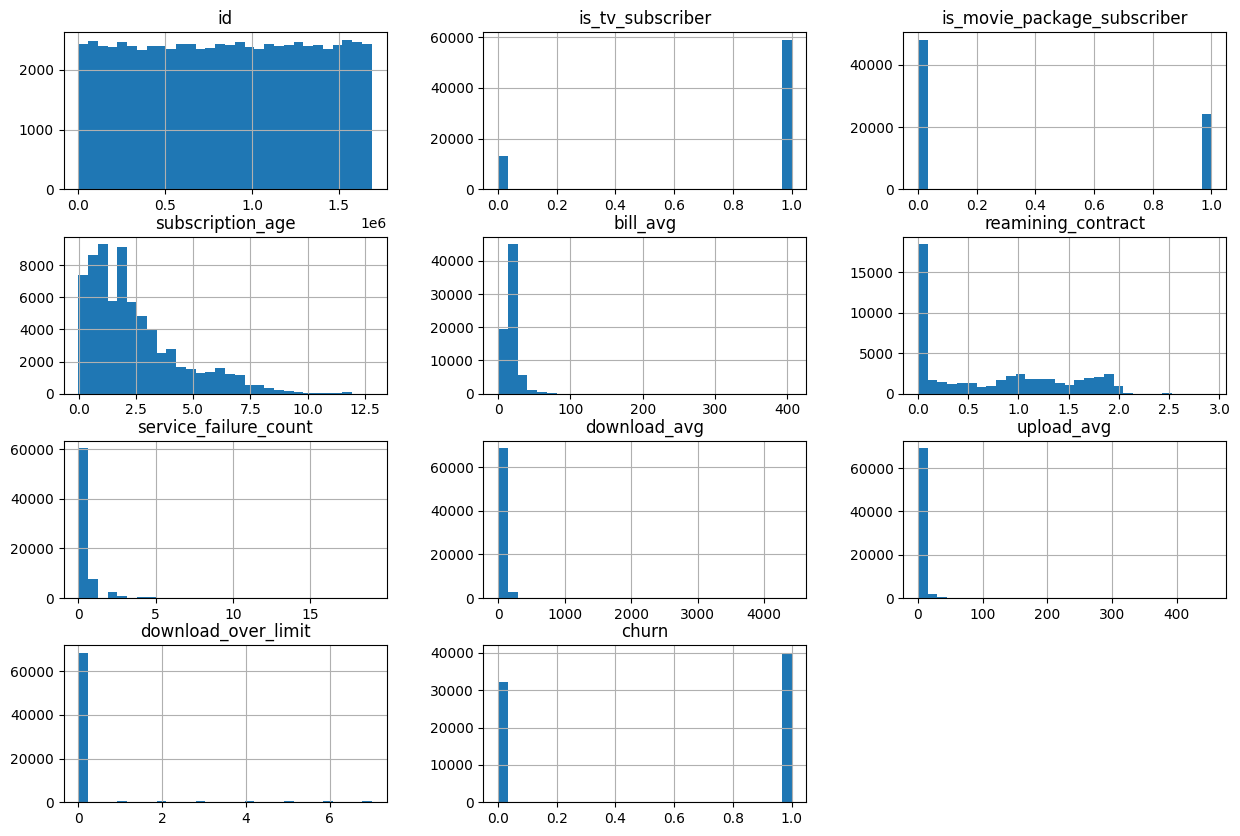

In [9]:
df_internet.hist(bins=30, figsize=(15,10))
plt.show()

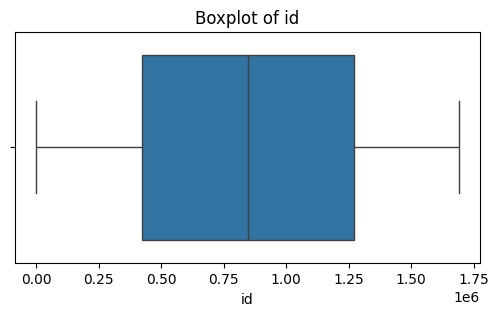

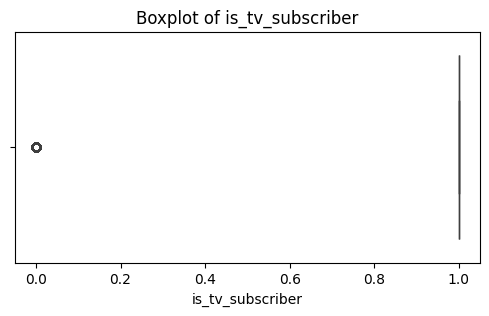

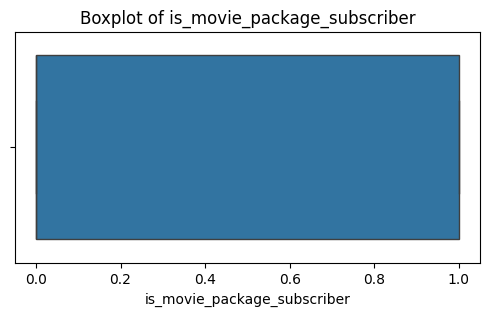

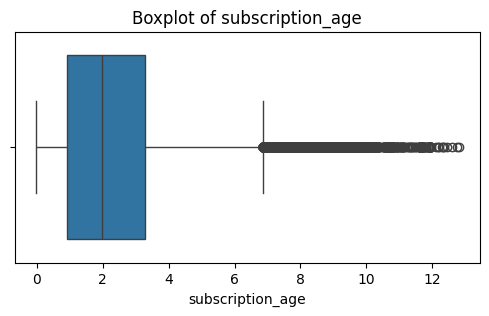

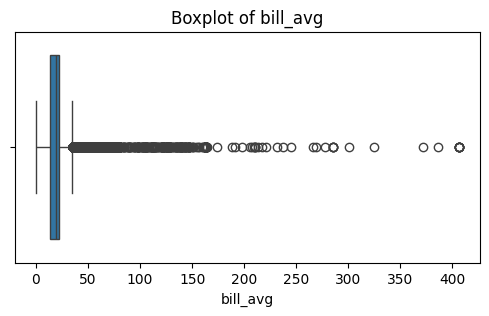

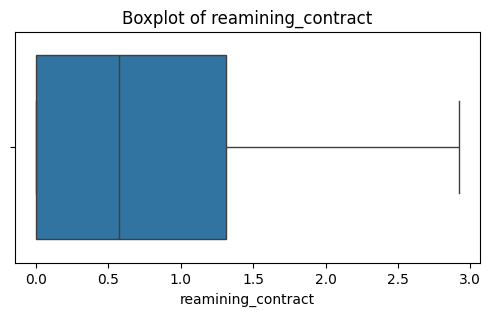

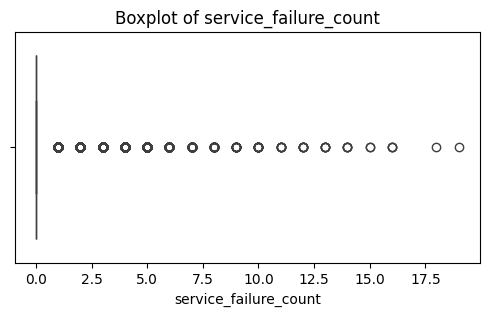

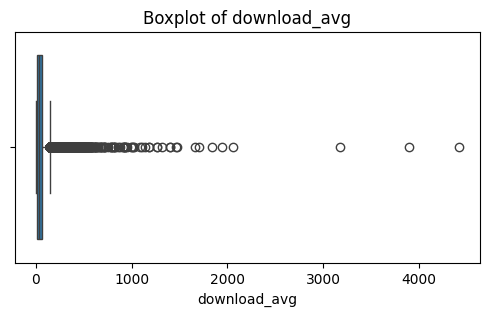

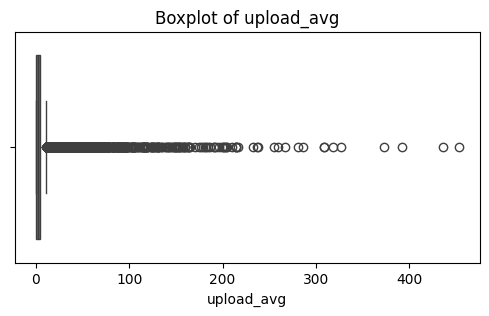

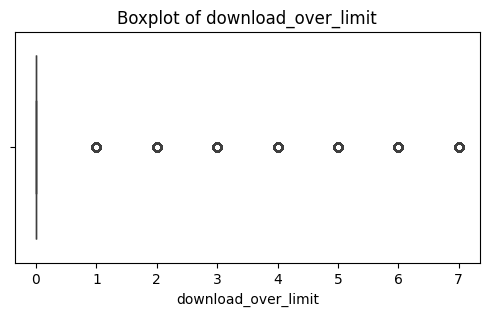

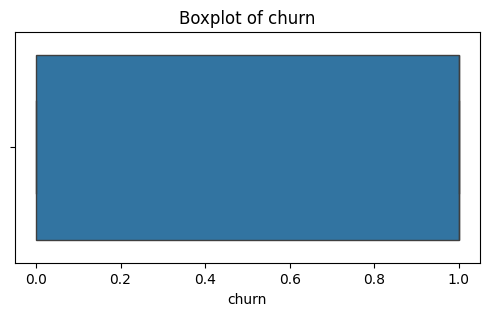

In [10]:
numeric_cols = df_internet.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df_internet[col])
    plt.title(f'Boxplot of {col}')
    plt.show()